In [1]:
# If SHAP is not installed, run:
# !pip install shap xgboost scikit-learn pandas matplotlib seaborn

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
DATA_PATH = "cleaned_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (18363, 61)

Columns:
['serial_number', 'project_id', 'project_code', 'legacy_ocms_code', 'pmgid', 'project_name', 'agency', 'state', 'date_of_approval', 'start_date', 'original_completion_date', 'revised_completion_date', 'actual_completion_date', 'original_cost', 'revised_cost', 'cumulative_expenditure', 'physical_progress', 'status', 'source_page', 'source_pdf', 'report_month', 'table_name', 'ministry', 'sector', 'report_date', 'date_of_approval_raw', 'start_date_raw', 'original_completion_date_raw', 'planned_duration_months', 'raw_project_age_months', 'remaining_planned_duration', 'not_started_flag', 'project_age_months', 'planned_duration', 'project_age', 'missing_date_flag', 'source_date_error_flag', 'date_order_inconsistency_flag', 'genuine_overdue_flag', 'expenditure_percent_original', 'cost_overrun', 'cost_overrun_percent', 'delay_months', 'progress_change', 'expenditure_change', 'cost_revision_change', 'schedule_revision', 'target_cost_overrun_final', 'target_d

In [3]:
FEATURE_COLS = [
    "original_cost",
    "revised_cost",
    "cumulative_expenditure",
    "physical_progress",
    "expenditure_percent_original",
    "project_age_months",
    "remaining_planned_duration",
    "planned_duration",
    "not_started_flag",
    "genuine_overdue_flag",
    "ministry_encoded",
    "sector_encoded",
    "state_encoded"
]

# Make sure features exist
missing_features = [c for c in FEATURE_COLS if c not in df.columns]

if missing_features:
    print("Missing features:", missing_features)
else:
    print("All features available.")

All features available.


In [4]:
df = df.sort_values(
    ["project_code", "report_date"]
).copy()

# Future actual values
df["future_cost_overrun_percent"] = (
    df.groupby("project_code")["cost_overrun_percent"].shift(-1)
)

df["future_delay_months"] = (
    df.groupby("project_code")["delay_months"].shift(-1)
)

print(
    df[
        [
            "project_code",
            "report_date",
            "cost_overrun_percent",
            "future_cost_overrun_percent",
            "delay_months",
            "future_delay_months"
        ]
    ].head(10)
)

   project_code report_date  cost_overrun_percent  \
0         40000  2025-04-01                   NaN   
1         40000  2025-05-01            -53.118774   
2         40000  2026-02-01             18.850575   
3         40001  2025-04-01              0.000000   
4         40001  2025-05-01              0.000000   
5         40001  2026-02-01            726.631139   
6         40001  2026-03-01             66.786692   
7         60000  2025-04-01                   NaN   
8         60000  2025-05-01                   NaN   
9         60001  2025-04-01                   NaN   

   future_cost_overrun_percent  delay_months  future_delay_months  
0                   -53.118774           NaN                  NaN  
1                    18.850575           NaN                 10.0  
2                          NaN          10.0                  NaN  
3                     0.000000           NaN                  NaN  
4                   726.631139           NaN                 23.0  
5       

In [5]:
def bucket_cost_overrun(x):
    if pd.isna(x):
        return np.nan
    elif x <= 0:
        return "No overrun"
    elif x <= 10:
        return "Minor (0-10%)"
    elif x <= 40:
        return "Moderate (10-40%)"
    else:
        return "Major (>40%)"


df["future_cost_bucket"] = (
    df["future_cost_overrun_percent"]
    .apply(bucket_cost_overrun)
)

print(df["future_cost_bucket"].value_counts(dropna=False))

future_cost_bucket
No overrun           11588
NaN                   2418
Moderate (10-40%)     1594
Major (>40%)          1498
Minor (0-10%)         1265
Name: count, dtype: int64


In [6]:
def bucket_delay(x):
    if pd.isna(x):
        return np.nan
    elif x <= 3:
        return "Low (<=3 mo)"
    elif x <= 15:
        return "Moderate (3-15 mo)"
    elif x <= 40:
        return "High (15-40 mo)"
    else:
        return "Severe (>40 mo)"


df["future_delay_bucket"] = (
    df["future_delay_months"]
    .apply(bucket_delay)
)

print(df["future_delay_bucket"].value_counts(dropna=False))

future_delay_bucket
NaN                   6462
High (15-40 mo)       3482
Low (<=3 mo)          3167
Moderate (3-15 mo)    3135
Severe (>40 mo)       2117
Name: count, dtype: int64


In [7]:
def get_shap_reasons(model, X_row, feature_names, top_n=5):
    """
    Returns top features contributing to the model prediction.
    """

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_row)

    # Handle binary classification
    if isinstance(shap_values, list):
        values = shap_values[-1][0]
    else:
        shap_values = np.asarray(shap_values)

        if shap_values.ndim == 3:
            values = shap_values[0, :, -1]
        elif shap_values.ndim == 2:
            values = shap_values[0]
        else:
            values = shap_values.flatten()

    importance = pd.DataFrame({
        "feature": feature_names,
        "shap_value": values,
        "abs_shap": np.abs(values),
        "feature_value": X_row.iloc[0].values
    })

    importance = importance.sort_values(
        "abs_shap",
        ascending=False
    )

    return importance.head(top_n)

In [8]:
FEATURE_REASON_TEXT = {

    "original_cost":
        "The original project cost is influencing the prediction.",

    "revised_cost":
        "The revised project cost is influencing the prediction.",

    "cumulative_expenditure":
        "Cumulative expenditure is influencing the prediction.",

    "physical_progress":
        "Current physical progress is influencing the prediction.",

    "expenditure_percent_original":
        "Expenditure relative to the original budget is influencing the prediction.",

    "project_age_months":
        "The age of the project is influencing the prediction.",

    "remaining_planned_duration":
        "The remaining planned project duration is influencing the prediction.",

    "planned_duration":
        "The overall planned project duration is influencing the prediction.",

    "not_started_flag":
        "Project start/progress status is influencing the prediction.",

    "genuine_overdue_flag":
        "The project's overdue status is strongly influencing the prediction.",

    "ministry_encoded":
        "The ministry/administrative category is influencing the prediction.",

    "sector_encoded":
        "The project sector is influencing the prediction.",

    "state_encoded":
        "The project state/location category is influencing the prediction."
}

In [9]:
PRESCRIPTIONS = {

    "original_cost":
        "Review the original cost estimate and validate the remaining budget requirement.",

    "revised_cost":
        "Investigate cost revisions and identify the activities responsible for escalation.",

    "cumulative_expenditure":
        "Review expenditure against completed work and investigate unusually high spending.",

    "physical_progress":
        "Prioritize incomplete critical activities and introduce a short-term recovery plan.",

    "expenditure_percent_original":
        "Compare expenditure with physical progress and investigate expenditure-progress mismatch.",

    "project_age_months":
        "Review long-running activities and identify unresolved execution bottlenecks.",

    "remaining_planned_duration":
        "Prepare a recovery schedule and prioritize activities with limited remaining time.",

    "planned_duration":
        "Review the project schedule and reassess whether the planned duration remains realistic.",

    "not_started_flag":
        "Immediately identify activities that have not started and remove their execution bottlenecks.",

    "genuine_overdue_flag":
        "Create an overdue recovery plan and monitor critical activities more frequently.",

    "ministry_encoded":
        "Review administrative dependencies and escalate unresolved approvals or coordination issues.",

    "sector_encoded":
        "Review sector-specific execution risks and strengthen project monitoring.",

    "state_encoded":
        "Review location-specific execution constraints and coordinate with the relevant authorities."
}

In [10]:
def generate_explanation(
    model,
    X_row,
    feature_names,
    top_n=5
):

    shap_df = get_shap_reasons(
        model,
        X_row,
        feature_names,
        top_n=top_n
    )

    reasons = []
    prescriptions = []

    for _, row in shap_df.iterrows():

        feature = row["feature"]

        reason = FEATURE_REASON_TEXT.get(
            feature,
            f"{feature} is influencing the prediction."
        )

        prescription = PRESCRIPTIONS.get(
            feature,
            f"Review the project factor associated with {feature}."
        )

        reasons.append({
            "feature": feature,
            "shap_value": row["shap_value"],
            "reason": reason
        })

        prescriptions.append({
            "feature": feature,
            "prescription": prescription
        })

    return pd.DataFrame(reasons), pd.DataFrame(prescriptions)

In [11]:
def train_cost_model(df):

    target = "future_cost_bucket"

    data = df[
        FEATURE_COLS +
        ["project_code", target]
    ].copy()

    data = data.dropna()

    print("Cost model rows:", len(data))
    print(
        "Cost model projects:",
        data["project_code"].nunique()
    )

    X = data[FEATURE_COLS]
    y_raw = data[target]

    # Encode labels
    encoder = LabelEncoder()
    y = encoder.fit_transform(y_raw)

    # Group split by project
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.25,
        random_state=42
    )

    train_idx, test_idx = next(
        splitter.split(
            X,
            y,
            groups=data["project_code"]
        )
    )

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    # Baseline
    baseline = DummyClassifier(
        strategy="most_frequent"
    )

    baseline.fit(X_train, y_train)

    baseline_pred = baseline.predict(X_test)

    baseline_acc = accuracy_score(
        y_test,
        baseline_pred
    )

    # XGBoost
    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        pred
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro"
    )

    print("\n========== COST OVERRUN MODEL ==========")

    print("Baseline Accuracy:", round(baseline_acc, 4))
    print("Model Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            pred,
            target_names=encoder.classes_
        )
    )

    # Confusion matrix
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Cost Overrun Confusion Matrix")

    plt.show()

    return (
        model,
        encoder,
        X_test,
        y_test,
        data
    )

Cost model rows: 5931
Cost model projects: 1709

========== COST OVERRUN MODEL ==========
Baseline Accuracy: 0.7456
Model Accuracy: 0.8474
Macro F1: 0.6391

Classification Report:
                   precision    recall  f1-score   support

     Major (>40%)       0.79      0.82      0.80       109
    Minor (0-10%)       0.55      0.17      0.25       139
Moderate (10-40%)       0.64      0.52      0.58       117
       No overrun       0.88      0.97      0.93      1070

         accuracy                           0.85      1435
        macro avg       0.71      0.62      0.64      1435
     weighted avg       0.82      0.85      0.82      1435



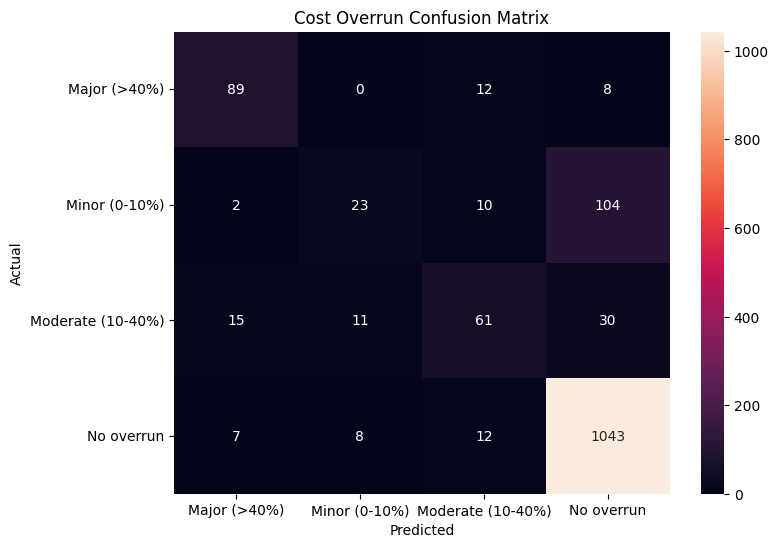

In [12]:
cost_model, cost_encoder, cost_X_test, cost_y_test, cost_data = (
    train_cost_model(df)
)

In [13]:
# Select a test project
cost_test_case = cost_X_test.iloc[[0]]

# Prediction
cost_prediction_encoded = cost_model.predict(
    cost_test_case
)[0]

cost_prediction = cost_encoder.inverse_transform(
    [cost_prediction_encoded]
)[0]

# Probabilities
cost_probabilities = cost_model.predict_proba(
    cost_test_case
)[0]

print("========== COST OVERRUN PREDICTION ==========")

print("Prediction:", cost_prediction)

print("\nProbabilities:")

for label, probability in zip(
    cost_encoder.classes_,
    cost_probabilities
):
    print(
        f"{label}: {probability * 100:.2f}%"
    )

========== COST OVERRUN PREDICTION ==========
Prediction: No overrun

Probabilities:
Major (>40%): 0.61%
Minor (0-10%): 0.15%
Moderate (10-40%): 0.16%
No overrun: 99.08%


In [14]:
cost_reasons, cost_prescriptions = generate_explanation(
    cost_model,
    cost_test_case,
    FEATURE_COLS,
    top_n=5
)

print("\n========== TOP COST OVERRUN REASONS ==========")

for i, row in cost_reasons.iterrows():

    direction = (
        "increasing"
        if row["shap_value"] > 0
        else "reducing"
    )

    print(
        f"{i + 1}. {row['feature']} "
        f"({direction} risk)"
    )

    print(
        "   ",
        row["reason"]
    )


========== TOP COST OVERRUN REASONS ==========
1. remaining_planned_duration (increasing risk)
    The remaining planned project duration is influencing the prediction.
2. revised_cost (increasing risk)
    The revised project cost is influencing the prediction.
3. ministry_encoded (increasing risk)
    The ministry/administrative category is influencing the prediction.
4. state_encoded (increasing risk)
    The project state/location category is influencing the prediction.
5. expenditure_percent_original (increasing risk)
    Expenditure relative to the original budget is influencing the prediction.


In [15]:
print("\n========== COST OVERRUN PRESCRIPTIONS ==========")

for i, row in cost_prescriptions.iterrows():

    print(
        f"{i + 1}. {row['prescription']}"
    )


========== COST OVERRUN PRESCRIPTIONS ==========
1. Prepare a recovery schedule and prioritize activities with limited remaining time.
2. Investigate cost revisions and identify the activities responsible for escalation.
3. Review administrative dependencies and escalate unresolved approvals or coordination issues.
4. Review location-specific execution constraints and coordinate with the relevant authorities.
5. Compare expenditure with physical progress and investigate expenditure-progress mismatch.


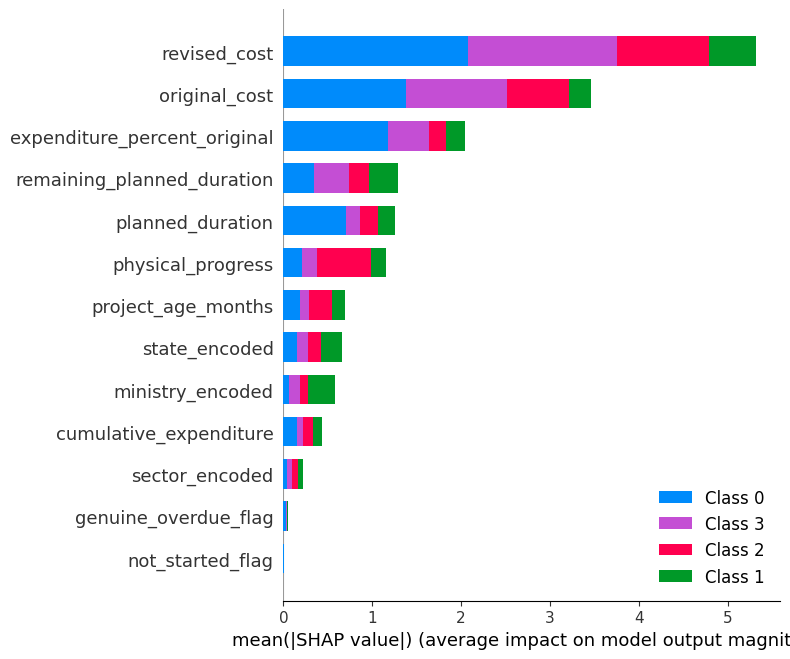

In [18]:
cost_explainer = shap.TreeExplainer(
    cost_model
)

cost_shap_values = cost_explainer(
    cost_X_test
)

shap.summary_plot(
    cost_shap_values,
    cost_X_test,
    show=True
)

In [19]:
def train_delay_model(df):

    target = "future_delay_bucket"

    data = df[
        FEATURE_COLS +
        ["project_code", target]
    ].copy()

    data = data.dropna()

    print("Delay model rows:", len(data))
    print(
        "Delay model projects:",
        data["project_code"].nunique()
    )

    X = data[FEATURE_COLS]
    y_raw = data[target]

    encoder = LabelEncoder()

    y = encoder.fit_transform(y_raw)

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.25,
        random_state=42
    )

    train_idx, test_idx = next(
        splitter.split(
            X,
            y,
            groups=data["project_code"]
        )
    )

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    # Baseline
    baseline = DummyClassifier(
        strategy="most_frequent"
    )

    baseline.fit(X_train, y_train)

    baseline_pred = baseline.predict(X_test)

    baseline_acc = accuracy_score(
        y_test,
        baseline_pred
    )

    # XGBoost
    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        pred
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro"
    )

    print("\n========== TIME / DELAY MODEL ==========")

    print("Baseline Accuracy:", round(baseline_acc, 4))
    print("Model Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            pred,
            target_names=encoder.classes_
        )
    )

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Future Delay Confusion Matrix")

    plt.show()

    return (
        model,
        encoder,
        X_test,
        y_test,
        data
    )

Delay model rows: 4815
Delay model projects: 1436

========== TIME / DELAY MODEL ==========
Baseline Accuracy: 0.2884
Model Accuracy: 0.7906
Macro F1: 0.793

Classification Report:
                    precision    recall  f1-score   support

   High (15-40 mo)       0.77      0.82      0.79       336
      Low (<=3 mo)       0.77      0.76      0.77       277
Moderate (3-15 mo)       0.74      0.71      0.72       293
   Severe (>40 mo)       0.90      0.88      0.89       259

          accuracy                           0.79      1165
         macro avg       0.80      0.79      0.79      1165
      weighted avg       0.79      0.79      0.79      1165



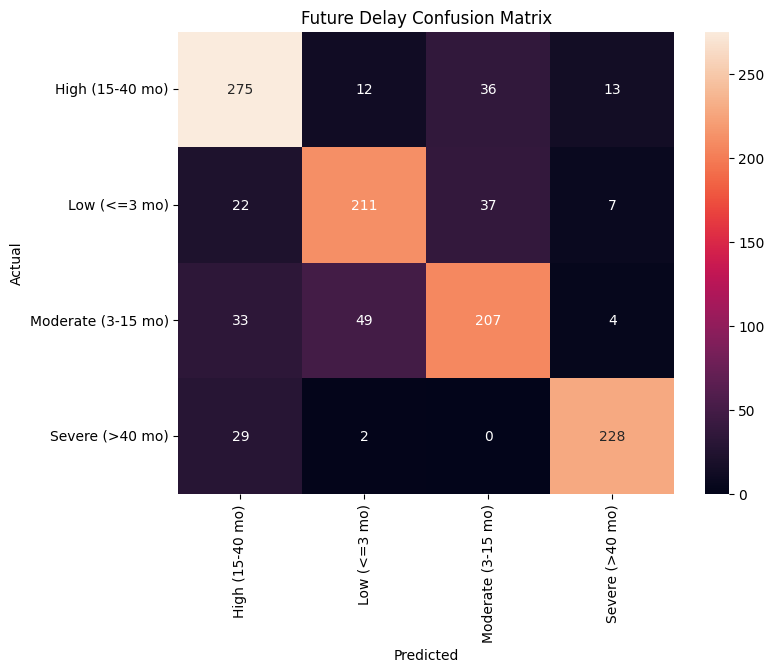

In [20]:
delay_model, delay_encoder, delay_X_test, delay_y_test, delay_data = (
    train_delay_model(df)
)

In [21]:
delay_test_case = delay_X_test.iloc[[0]]

delay_prediction_encoded = delay_model.predict(
    delay_test_case
)[0]

delay_prediction = delay_encoder.inverse_transform(
    [delay_prediction_encoded]
)[0]

delay_probabilities = delay_model.predict_proba(
    delay_test_case
)[0]

print("========== TIME OVERRUN PREDICTION ==========")

print("Prediction:", delay_prediction)

print("\nProbabilities:")

for label, probability in zip(
    delay_encoder.classes_,
    delay_probabilities
):

    print(
        f"{label}: {probability * 100:.2f}%"
    )

========== TIME OVERRUN PREDICTION ==========
Prediction: Severe (>40 mo)

Probabilities:
High (15-40 mo): 0.11%
Low (<=3 mo): 0.09%
Moderate (3-15 mo): 0.01%
Severe (>40 mo): 99.79%


In [22]:
delay_reasons, delay_prescriptions = generate_explanation(
    delay_model,
    delay_test_case,
    FEATURE_COLS,
    top_n=5
)

print("\n========== TOP TIME OVERRUN REASONS ==========")

for i, row in delay_reasons.iterrows():

    direction = (
        "increasing"
        if row["shap_value"] > 0
        else "reducing"
    )

    print(
        f"{i + 1}. {row['feature']} "
        f"({direction} risk)"
    )

    print(
        "   ",
        row["reason"]
    )


========== TOP TIME OVERRUN REASONS ==========
1. remaining_planned_duration (increasing risk)
    The remaining planned project duration is influencing the prediction.
2. physical_progress (increasing risk)
    Current physical progress is influencing the prediction.
3. project_age_months (increasing risk)
    The age of the project is influencing the prediction.
4. expenditure_percent_original (reducing risk)
    Expenditure relative to the original budget is influencing the prediction.
5. planned_duration (increasing risk)
    The overall planned project duration is influencing the prediction.


In [23]:
print("\n========== TIME OVERRUN PRESCRIPTIONS ==========")

for i, row in delay_prescriptions.iterrows():

    print(
        f"{i + 1}. {row['prescription']}"
    )


========== TIME OVERRUN PRESCRIPTIONS ==========
1. Prepare a recovery schedule and prioritize activities with limited remaining time.
2. Prioritize incomplete critical activities and introduce a short-term recovery plan.
3. Review long-running activities and identify unresolved execution bottlenecks.
4. Compare expenditure with physical progress and investigate expenditure-progress mismatch.
5. Review the project schedule and reassess whether the planned duration remains realistic.


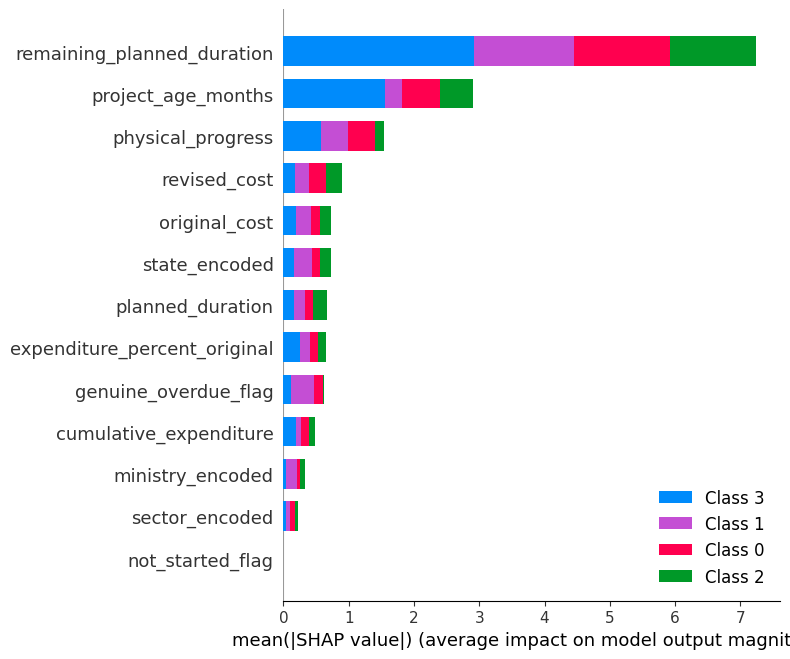

In [24]:
delay_explainer = shap.TreeExplainer(
    delay_model
)

delay_shap_values = delay_explainer(
    delay_X_test
)

shap.summary_plot(
    delay_shap_values,
    delay_X_test,
    show=True
)

In [25]:
def train_risk_model(df):

    target = "target_future_risk"

    data = df[
        FEATURE_COLS +
        ["project_code", target]
    ].copy()

    data = data.dropna()

    print("Risk model rows:", len(data))
    print(
        "Risk model projects:",
        data["project_code"].nunique()
    )

    X = data[FEATURE_COLS]

    y = data[target].astype(int)

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.25,
        random_state=42
    )

    train_idx, test_idx = next(
        splitter.split(
            X,
            y,
            groups=data["project_code"]
        )
    )

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Baseline
    baseline = DummyClassifier(
        strategy="most_frequent"
    )

    baseline.fit(
        X_train,
        y_train
    )

    baseline_pred = baseline.predict(
        X_test
    )

    baseline_acc = accuracy_score(
        y_test,
        baseline_pred
    )

    # XGBoost
    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    probability = model.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        pred
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro"
    )

    print("\n========== FUTURE RISK MODEL ==========")

    print(
        "Baseline Accuracy:",
        round(baseline_acc, 4)
    )

    print(
        "Model Accuracy:",
        round(accuracy, 4)
    )

    print(
        "Macro F1:",
        round(macro_f1, 4)
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            pred,
            target_names=[
                "Low Risk",
                "High Risk"
            ]
        )
    )

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=[
            "Low Risk",
            "High Risk"
        ],
        yticklabels=[
            "Low Risk",
            "High Risk"
        ]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Future Risk Confusion Matrix")

    plt.show()

    return (
        model,
        X_test,
        y_test,
        data
    )

Risk model rows: 5987
Risk model projects: 1718

========== FUTURE RISK MODEL ==========
Baseline Accuracy: 0.6984
Model Accuracy: 0.7401
Macro F1: 0.6777

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.84      0.82      1005
   High Risk       0.58      0.50      0.54       434

    accuracy                           0.74      1439
   macro avg       0.69      0.67      0.68      1439
weighted avg       0.73      0.74      0.73      1439



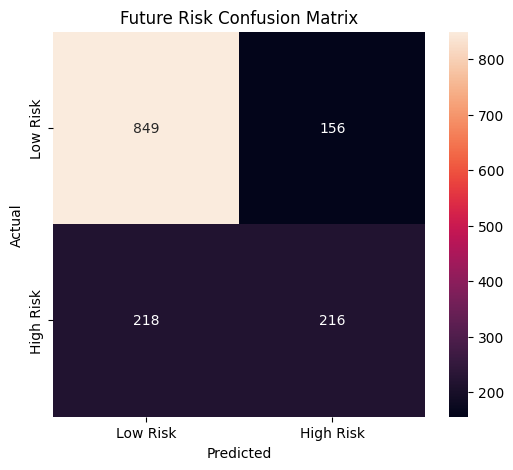

In [26]:
risk_model, risk_X_test, risk_y_test, risk_data = (
    train_risk_model(df)
)

In [27]:
def risk_level(probability):

    if probability < 0.33:
        return "Low"

    elif probability < 0.66:
        return "Medium"

    else:
        return "High"

In [28]:
risk_test_case = risk_X_test.iloc[[0]]

risk_probability = risk_model.predict_proba(
    risk_test_case
)[0, 1]

risk_percentage = risk_probability * 100

risk_category = risk_level(
    risk_probability
)

print("========== FUTURE PROJECT RISK ==========")

print(
    "Risk Level:",
    risk_category
)

print(
    f"Risk Probability: {risk_percentage:.2f}%"
)

========== FUTURE PROJECT RISK ==========
Risk Level: Low
Risk Probability: 1.96%


In [29]:
risk_reasons, risk_prescriptions = generate_explanation(
    risk_model,
    risk_test_case,
    FEATURE_COLS,
    top_n=5
)

print("\n========== TOP FUTURE RISK REASONS ==========")

for i, row in risk_reasons.iterrows():

    direction = (
        "increasing"
        if row["shap_value"] > 0
        else "reducing"
    )

    print(
        f"{i + 1}. {row['feature']} "
        f"({direction} risk)"
    )

    print(
        "   ",
        row["reason"]
    )



========== TOP FUTURE RISK REASONS ==========
1. remaining_planned_duration (reducing risk)
    The remaining planned project duration is influencing the prediction.
2. physical_progress (reducing risk)
    Current physical progress is influencing the prediction.
3. ministry_encoded (reducing risk)
    The ministry/administrative category is influencing the prediction.
4. planned_duration (increasing risk)
    The overall planned project duration is influencing the prediction.
5. state_encoded (reducing risk)
    The project state/location category is influencing the prediction.


In [30]:
print("\n========== RISK PRESCRIPTIONS ==========")

for i, row in risk_prescriptions.iterrows():

    print(
        f"{i + 1}. {row['prescription']}"
    )
    


========== RISK PRESCRIPTIONS ==========
1. Prepare a recovery schedule and prioritize activities with limited remaining time.
2. Prioritize incomplete critical activities and introduce a short-term recovery plan.
3. Review administrative dependencies and escalate unresolved approvals or coordination issues.
4. Review the project schedule and reassess whether the planned duration remains realistic.
5. Review location-specific execution constraints and coordinate with the relevant authorities.


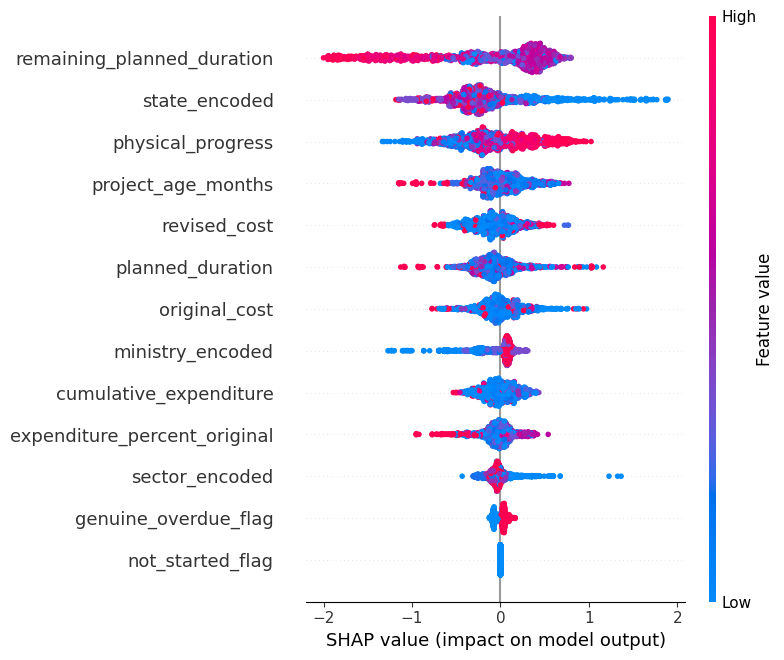

In [31]:
risk_explainer = shap.TreeExplainer(
    risk_model
)

risk_shap_values = risk_explainer(
    risk_X_test
)

shap.summary_plot(
    risk_shap_values,
    risk_X_test,
    show=True
)


In [32]:
def generate_project_report(
    project_row,
    cost_model,
    cost_encoder,
    delay_model,
    delay_encoder,
    risk_model
):

    X = project_row[FEATURE_COLS].to_frame().T

    # ==========================================
    # COST
    # ==========================================

    cost_encoded = cost_model.predict(X)[0]

    cost_prediction = cost_encoder.inverse_transform(
        [cost_encoded]
    )[0]

    cost_probs = cost_model.predict_proba(X)[0]

    cost_probability = np.max(cost_probs)

    cost_reasons, cost_prescriptions = (
        generate_explanation(
            cost_model,
            X,
            FEATURE_COLS,
            top_n=5
        )
    )

    # ==========================================
    # DELAY
    # ==========================================

    delay_encoded = delay_model.predict(X)[0]

    delay_prediction = delay_encoder.inverse_transform(
        [delay_encoded]
    )[0]

    delay_probs = delay_model.predict_proba(X)[0]

    delay_probability = np.max(delay_probs)

    delay_reasons, delay_prescriptions = (
        generate_explanation(
            delay_model,
            X,
            FEATURE_COLS,
            top_n=5
        )
    )

    # ==========================================
    # RISK
    # ==========================================

    risk_probability = risk_model.predict_proba(
        X
    )[0, 1]

    risk_percentage = risk_probability * 100

    risk_prediction = risk_level(
        risk_probability
    )

    risk_reasons, risk_prescriptions = (
        generate_explanation(
            risk_model,
            X,
            FEATURE_COLS,
            top_n=5
        )
    )

    # ==========================================
    # PRINT REPORT
    # ==========================================

    print("\n")
    print("=" * 70)
    print("             PROJECT PREDICTION REPORT")
    print("=" * 70)

    # COST
    print("\n💰 COST OVERRUN")
    print("-" * 50)

    print(
        "Prediction:",
        cost_prediction
    )

    print(
        f"Confidence: {cost_probability * 100:.2f}%"
    )

    print("\nTop Reasons:")

    for i, row in cost_reasons.iterrows():

        print(
            f"{i + 1}. {row['reason']}"
        )

    print("\nPrescriptions:")

    for i, row in cost_prescriptions.iterrows():

        print(
            f"{i + 1}. {row['prescription']}"
        )

    # DELAY
    print("\n\n⏱️ TIME / DELAY OVERRUN")
    print("-" * 50)

    print(
        "Prediction:",
        delay_prediction
    )

    print(
        f"Confidence: {delay_probability * 100:.2f}%"
    )

    print("\nTop Reasons:")

    for i, row in delay_reasons.iterrows():

        print(
            f"{i + 1}. {row['reason']}"
        )

    print("\nPrescriptions:")

    for i, row in delay_prescriptions.iterrows():

        print(
            f"{i + 1}. {row['prescription']}"
        )

    # RISK
    print("\n\n⚠️ FUTURE PROJECT RISK")
    print("-" * 50)

    print(
        "Risk Level:",
        risk_prediction
    )

    print(
        f"Risk Percentage: {risk_percentage:.2f}%"
    )

    print("\nTop Reasons:")

    for i, row in risk_reasons.iterrows():

        print(
            f"{i + 1}. {row['reason']}"
        )

    print("\nPrescriptions:")

    for i, row in risk_prescriptions.iterrows():

        print(
            f"{i + 1}. {row['prescription']}"
        )

    print("\n")
    print("=" * 70)

    return {
        "cost_prediction": cost_prediction,
        "cost_probability": cost_probability,

        "cost_reasons": cost_reasons,
        "cost_prescriptions": cost_prescriptions,

        "delay_prediction": delay_prediction,
        "delay_probability": delay_probability,

        "delay_reasons": delay_reasons,
        "delay_prescriptions": delay_prescriptions,

        "risk_level": risk_prediction,
        "risk_percentage": risk_percentage,

        "risk_reasons": risk_reasons,
        "risk_prescriptions": risk_prescriptions
    }

In [33]:
project = risk_X_test.iloc[0]

report = generate_project_report(
    project,
    cost_model,
    cost_encoder,
    delay_model,
    delay_encoder,
    risk_model
)



             PROJECT PREDICTION REPORT

💰 COST OVERRUN
--------------------------------------------------
Prediction: No overrun
Confidence: 99.08%

Top Reasons:
1. The remaining planned project duration is influencing the prediction.
2. The revised project cost is influencing the prediction.
3. The ministry/administrative category is influencing the prediction.
4. The project state/location category is influencing the prediction.
5. Expenditure relative to the original budget is influencing the prediction.

Prescriptions:
1. Prepare a recovery schedule and prioritize activities with limited remaining time.
2. Investigate cost revisions and identify the activities responsible for escalation.
3. Review administrative dependencies and escalate unresolved approvals or coordination issues.
4. Review location-specific execution constraints and coordinate with the relevant authorities.
5. Compare expenditure with physical progress and investigate expenditure-progress mismatch.


⏱️ TIME / 

In [34]:
def predict_project_by_code(
    project_code,
    df,
    cost_model,
    cost_encoder,
    delay_model,
    delay_encoder,
    risk_model
):

    project_rows = df[
        df["project_code"] == project_code
    ].sort_values("report_date")

    if len(project_rows) == 0:
        print("Project not found.")
        return None

    # Most recent available report
    project = project_rows.iloc[-1]

    print(
        "\nProject:",
        project_code
    )

    print(
        "Latest report:",
        project["report_date"]
    )

    return generate_project_report(
        project,
        cost_model,
        cost_encoder,
        delay_model,
        delay_encoder,
        risk_model
    )

In [35]:
project_code = df["project_code"].dropna().iloc[0]

report = predict_project_by_code(
    project_code,
    df,
    cost_model,
    cost_encoder,
    delay_model,
    delay_encoder,
    risk_model
)


Project: 40000
Latest report: 2026-02-01


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:original_cost: object, revised_cost: object, cumulative_expenditure: object, physical_progress: object, expenditure_percent_original: object, project_age_months: object, remaining_planned_duration: object, planned_duration: object, not_started_flag: object, genuine_overdue_flag: object, ministry_encoded: object, sector_encoded: object, state_encoded: object